In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


telco_churn  = pd.read_csv("data/telco_churn.csv")

In [2]:
print(telco_churn.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
print(telco_churn.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


observed that total charges has string value of " " instead of nan and its dtype is str which is escaping the isna(). so we replace " " with nan, convert its dtype to float,then run isna() to check for missing values again

In [4]:
telco_churn.replace("", np.nan, inplace=True)

telco_churn['TotalCharges']=pd.to_numeric(telco_churn["TotalCharges"], errors='coerce')

print(telco_churn.isna().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


as there are only 11 rows that have missing values, we will drop them instead of adding filler values.

In [5]:
telco_churn=telco_churn.dropna()

print(telco_churn.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

checking for skewness of churn

In [6]:
skew = telco_churn["Churn"].value_counts()
print(skew)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


there is a class imbalance.

checking tenure spread

In [7]:
tenure = telco_churn["tenure"].describe()
print(tenure)

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


Axes(0.125,0.11;0.775x0.77)


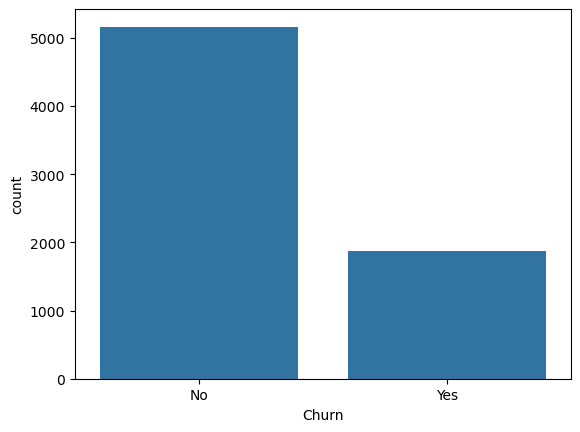

In [8]:
print(sns.countplot(telco_churn, x="Churn"))

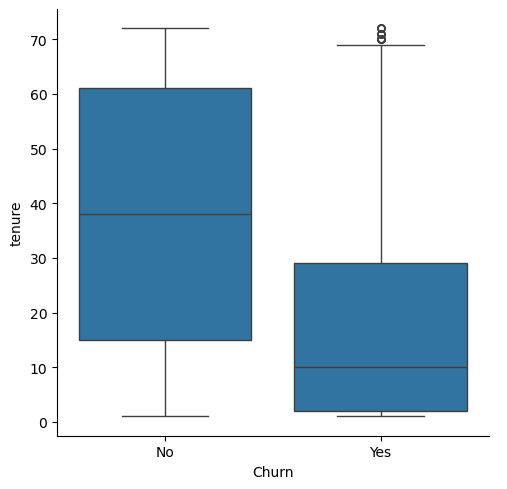

In [9]:
print(sns.catplot(data=telco_churn, x="Churn", y="tenure",kind="box"))

we see that newer customers churn more

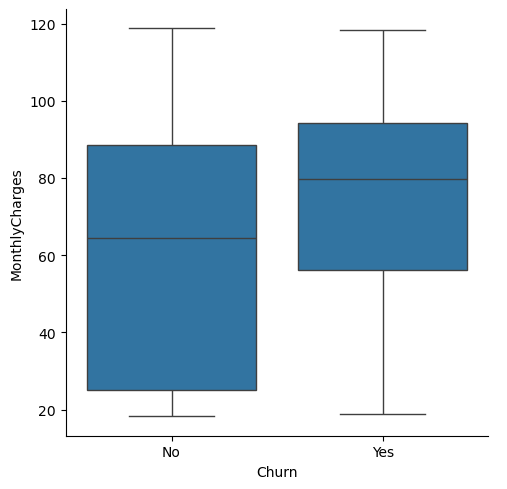

In [10]:
print(sns.catplot(telco_churn, x="Churn", y="MonthlyCharges", kind="box"))

we observe expensive plans churn more

In [11]:
numerical = telco_churn.select_dtypes(include=[np.number])
print(numerical)

      SeniorCitizen  tenure  MonthlyCharges  TotalCharges
0                 0       1           29.85         29.85
1                 0      34           56.95       1889.50
2                 0       2           53.85        108.15
3                 0      45           42.30       1840.75
4                 0       2           70.70        151.65
...             ...     ...             ...           ...
7038              0      24           84.80       1990.50
7039              0      72          103.20       7362.90
7040              0      11           29.60        346.45
7041              1       4           74.40        306.60
7042              0      66          105.65       6844.50

[7032 rows x 4 columns]


In [12]:
correlation_matrix = numerical.corr()

Axes(0.125,0.11;0.62x0.77)


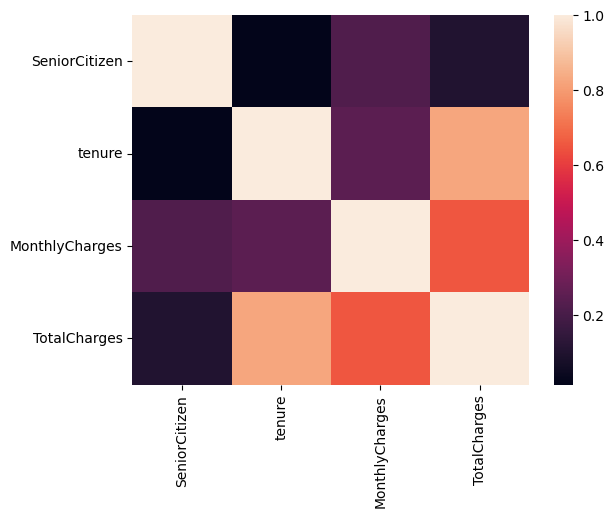

In [13]:
print(sns.heatmap(correlation_matrix))

stribgest relations- tenure and total charges, monthly charges and total charges are predictable, senior citizen is the weakest relationship here(can be removed)

CustomerID is not a feature and SeniorCitizen is weak as we can see in the heatmap. so we drop both.


In [14]:
telco_churn = telco_churn.drop(columns=['customerID', 'SeniorCitizen'])

In [15]:
print(telco_churn.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   Partner           7032 non-null   object 
 2   Dependents        7032 non-null   object 
 3   tenure            7032 non-null   int64  
 4   PhoneService      7032 non-null   object 
 5   MultipleLines     7032 non-null   object 
 6   InternetService   7032 non-null   object 
 7   OnlineSecurity    7032 non-null   object 
 8   OnlineBackup      7032 non-null   object 
 9   DeviceProtection  7032 non-null   object 
 10  TechSupport       7032 non-null   object 
 11  StreamingTV       7032 non-null   object 
 12  StreamingMovies   7032 non-null   object 
 13  Contract          7032 non-null   object 
 14  PaperlessBilling  7032 non-null   object 
 15  PaymentMethod     7032 non-null   object 
 16  MonthlyCharges    7032 non-null   float64
 17  

columns dropped successfully

In [16]:
telco_churn.select_dtypes(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


In [17]:
telco_churn['Churn'] = telco_churn['Churn'].map({'Yes': 1, 'No': 0})


In [18]:
telco_churn['gender'] = telco_churn['gender'].map({'Male': 1, 'Female': 0})

In [19]:
telco_churn['Partner'] = telco_churn['Partner'].map({'Yes': 1, 'No': 0})

In [20]:
telco_churn['Dependents'] = telco_churn['Dependents'].map({'Yes': 1, 'No': 0})

In [21]:
telco_churn['PhoneService'] = telco_churn['PhoneService'].map({'Yes': 1, 'No': 0})

In [22]:
telco_churn['MultipleLines'] = telco_churn['MultipleLines'].replace('No phone service','No')

In [23]:
telco_churn=pd.get_dummies(telco_churn,columns=['MultipleLines'], drop_first=True, dtype = int)

In [24]:
telco_churn=pd.get_dummies(telco_churn,columns=['InternetService'], drop_first=True, dtype = int)

In [25]:
telco_churn=pd.get_dummies(telco_churn,columns=['OnlineSecurity'], drop_first=True, dtype = int)

In [26]:
telco_churn=pd.get_dummies(telco_churn,columns=['OnlineBackup'], drop_first=True, dtype = int)

In [27]:
telco_churn=pd.get_dummies(telco_churn,columns=['DeviceProtection'], drop_first=True, dtype = int)

In [28]:
telco_churn=pd.get_dummies(telco_churn,columns=['TechSupport'], drop_first=True, dtype = int)

In [29]:
telco_churn=pd.get_dummies(telco_churn,columns=['StreamingMovies'], drop_first=True, dtype = int)

In [30]:
telco_churn=pd.get_dummies(telco_churn,columns=['StreamingTV'], drop_first=True, dtype = int)

In [31]:
telco_churn['PaperlessBilling'] = telco_churn['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [32]:
telco_churn = pd.get_dummies(telco_churn, columns=['Contract'], drop_first=True, dtype=int)

In [33]:
telco_churn = pd.get_dummies(telco_churn, columns=['PaymentMethod'], drop_first=True, dtype=int)

In [34]:
X= telco_churn.drop('Churn', axis=1)
y=telco_churn['Churn']

In [41]:

from sklearn.preprocessing import StandardScaler
scale_cols=['tenure','MonthlyCharges','TotalCharges']
scaler= StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])
model= LogisticRegression(solver='saga',max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


In [42]:
model.score(X_test, y_test)

0.7882018479033405

In [45]:
y_pred = model.predict(X_test)

In [46]:
print(y_pred)

[0 0 1 ... 0 0 0]


In [47]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))

[[915 118]
 [180 194]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



LR recall on churners is 0.52 due to class imbalance — model misses ~half of actual churns. Random Forest next for comparison

In [59]:
from sklearn.ensemble import RandomForestClassifier

RFmodel= RandomForestClassifier()
RFmodel.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
RFmodel.score(X_test, y_test)

0.7782515991471215

In [61]:
y_pred = model.predict(X_test)
print(y_pred)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))

[0 0 1 ... 0 0 0]
[[938  95]
 [206 168]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.45      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.79      0.77      1407



In [62]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False).head(10))

TotalCharges                      0.202531
MonthlyCharges                    0.176579
tenure                            0.174878
InternetService_Fiber optic       0.044000
PaymentMethod_Electronic check    0.037201
Contract_Two year                 0.035344
gender                            0.028079
PaperlessBilling                  0.024992
TechSupport_Yes                   0.024104
Contract_One year                 0.023950
dtype: float64


In [63]:
import joblib
joblib.dump(RFmodel, 'churn_model.pkl')


['churn_model.pkl']